# Tree-Based Machine Learning: From Decision Trees to XGBoost

## Overview

Tree-based learning algorithms are among the most powerful and widely used methods in modern machine learning. They form the foundation of many state-of-the-art systems used in finance, healthcare, recommendation systems, search ranking, fraud detection, and competitive machine learning.

Unlike linear models, tree-based methods can naturally capture nonlinear relationships, complex feature interactions, and heterogeneous decision boundaries without requiring extensive feature engineering.

This notebook develops tree-based learning from first principles. Rather than treating algorithms as black boxes, we will derive the mathematical ideas that motivate their design and study how increasingly sophisticated methods evolved from a single decision tree into powerful ensemble techniques such as Random Forests, Gradient Boosting, and XGBoost.

---

### Learning Objectives

By the end of this notebook, we will be able to:

- Explain how decision trees recursively partition data
- Derive entropy from information theory
- Compute information gain and evaluate candidate splits
- Understand impurity measures and split selection
- Analyze overfitting in decision trees
- Explain why ensemble methods outperform individual trees
- Understand bootstrap aggregation (bagging)
- Understand residual learning and gradient boosting
- Explain the core ideas behind XGBoost
- Compare major tree-based learning paradigms

---

### Roadmap

The notebook follows the historical evolution of tree-based learning:

Information Theory

↓

Decision Trees

↓

Random Forests

↓

Gradient Boosting

↓

XGBoost

Each stage addresses limitations of the previous one while preserving the fundamental idea of partitioning feature space into increasingly informative regions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42

# 1. Decision Trees and Recursive Partitioning

At their core, decision trees perform **recursive partitioning**.

The central idea is remarkably simple:

1. Start with the entire dataset.
2. Choose a feature and a threshold.
3. Split the dataset into smaller subsets.
4. Repeat the process on each subset.
5. Continue until a stopping criterion is reached.

Each split attempts to increase the homogeneity of the resulting groups.

For example, suppose we wish to predict whether a student passes an exam.

A decision process might look like:

```text
Study Hours > 5?
├── No  → Fail
└── Yes
     ├── Attendance > 80%?
     │      ├── No  → Fail
     │      └── Yes → Pass
```

Notice that the model is not fitting a single equation.

Instead, it is constructing a hierarchy of decisions that recursively divides the input space into increasingly pure regions.

This raises a fundamental question:

> How can we determine whether a split is good or bad?

To answer this question, we first need a quantitative measure of uncertainty.

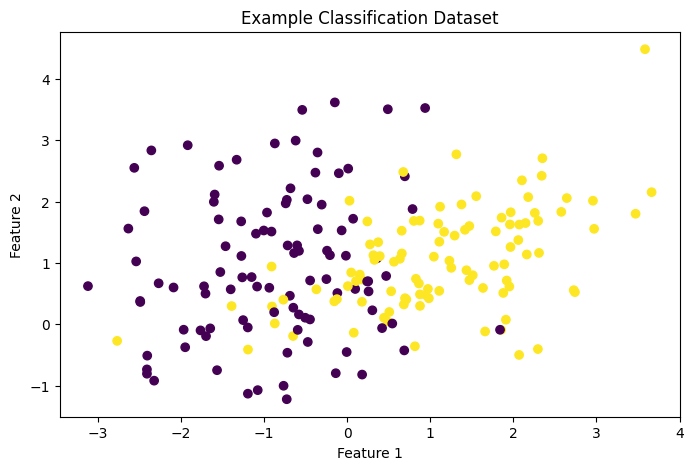

In [2]:
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=RANDOM_STATE
)

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Example Classification Dataset")
plt.show()

The dataset above contains two classes that must be separated.

A decision tree will repeatedly partition this feature space using axis-aligned splits of the form:

\[
x_j < t
\]

where:

- \(x_j\) is a feature
- \(t\) is a threshold

Each split divides the data into two child nodes.

The quality of a split depends on how effectively it reduces uncertainty about the target variable.

To formalize this idea, we now turn to information theory.

# 2. Information Theory Foundations

Decision trees require a quantitative measure of uncertainty.

Intuitively:

- A node containing samples from only one class is highly certain.
- A node containing an equal mixture of classes is highly uncertain.

To construct such a measure, we begin with a fundamental concept from information theory known as **self-information**.

Information theory was introduced by Claude Shannon in 1948 and provides a mathematical framework for quantifying uncertainty and information.

The central idea is simple:

> Rare events are more informative than common events.

For example:

- Observing that the sun rises tomorrow provides little new information because it is highly probable.
- Observing snow in the Sahara would provide substantial information because it is highly improbable.

To formalize this intuition, we define the information content of an event.

## 2.1 Self-Information

Suppose an event occurs with probability

$$
p(x).
$$

The information gained by observing that event is defined as

$$
I(x) = -\log_2(p(x)).
$$

This definition possesses several desirable properties.

### Property 1: Certain Events Carry No Information

If an event is guaranteed to occur,

$$
p(x)=1,
$$

then

$$
I(x)
=
-\log_2(1)
=
0.
$$

Observing a certain event teaches us nothing new.

### Property 2: Rare Events Carry More Information

If

$$
p(x)=0.5,
$$

then

$$
I(x)
=
-\log_2(0.5)
=
1.
$$

If

$$
p(x)=0.125,
$$

then

$$
I(x)
=
-\log_2(0.125)
=
3.
$$

Thus, less probable events produce larger amounts of information.

### Property 3: Information is Always Non-Negative

Since

$$
0 < p(x) \le 1,
$$

we have

$$
-\log_2(p(x)) \ge 0.
$$

Therefore information content can never be negative.

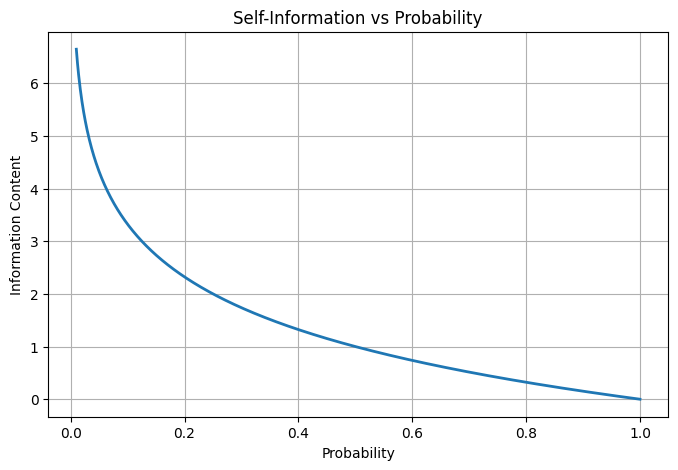

In [3]:
p = np.linspace(0.01, 1, 1000)

information = -np.log2(p)

plt.plot(p, information, linewidth=2)
plt.xlabel("Probability")
plt.ylabel("Information Content")
plt.title("Self-Information vs Probability")
plt.grid(True)
plt.show()

### Observations

The relationship between probability and information content is highly nonlinear.

As probability approaches zero,

$$
-\log_2(p)
$$

increases rapidly.

This reflects an intuitive principle:

> The more surprising an event is, the more information we gain when it occurs.

However, decision trees are not concerned with the information content of a single observation.

Instead, they require a measure of the **average uncertainty** associated with an entire probability distribution.

This leads naturally to the concept of entropy.

## 2.2 Entropy

Consider a random variable that can belong to one of $K$ classes.

Let

$$
p_i
$$

denote the probability of observing class $i$.

The expected information obtained from observing the class label is

$$
H(S)
=
\sum_{i=1}^{K}
p_i \, I(i).
$$

Substituting the definition of self-information,

$$
I(i)
=
-\log_2(p_i),
$$

gives

$$
H(S)
=
-\sum_{i=1}^{K}
p_i \log_2(p_i).
$$

This quantity is known as **Shannon Entropy**.

Entropy measures the average uncertainty of a probability distribution.

For a dataset $S$,

$$
H(S)
=
-\sum_{i=1}^{K}
p_i \log_2(p_i).
$$

where:

- $K$ is the number of classes
- $p_i$ is the probability of class $i$

Decision trees use entropy to determine how mixed a node is.

- A highly mixed node has **large entropy**.
- A highly pure node has **small entropy**.

### Interpretation

Entropy quantifies uncertainty in the class labels:

- Higher entropy $\rightarrow$ greater uncertainty
- Lower entropy $\rightarrow$ greater purity
- Zero entropy $\rightarrow$ all samples belong to a single class

The goal of a decision tree is to create splits that reduce entropy as much as possible, producing increasingly pure child nodes.

## 2.3 Understanding Entropy Through Examples

Entropy becomes easier to understand by evaluating it for different class distributions.

Recall that

$$
H(S)
=
-\sum_{i=1}^{K}
p_i \log_2(p_i).
$$

### Example 1: Perfectly Pure Node

Suppose all observations belong to a single class.

$$
p_1 = 1
$$

Then

$$
H(S)
=
-(1)\log_2(1)
=
0.
$$

The node contains no uncertainty because the class label is already known.

**Interpretation:** A pure node requires no additional information to determine the class.

---

### Example 2: Perfectly Balanced Node

Suppose a binary classification problem contains equal numbers of both classes.

$$
p_1 = 0.5,
\qquad
p_2 = 0.5
$$

Then

$$
H(S)
=
-(0.5\log_2 0.5 + 0.5\log_2 0.5)
=
1.
$$

This represents the maximum possible uncertainty for a binary classification problem.

**Interpretation:** Before observing the label, both classes are equally likely.

---

### Example 3: Imbalanced Node

Suppose

$$
p_1 = 0.9,
\qquad
p_2 = 0.1
$$

Then

$$
H(S)
=
-(0.9\log_2 0.9
+
0.1\log_2 0.1)
\approx 0.469.
$$

The node is relatively pure and therefore exhibits lower entropy.

**Interpretation:** Most observations belong to one class, so uncertainty is substantially reduced.

---

### Key Observation

For binary classification:

| Class Distribution | Entropy |
|----------|----------|
| (1.0, 0.0) | 0.000 |
| (0.9, 0.1) | 0.469 |
| (0.8, 0.2) | 0.722 |
| (0.7, 0.3) | 0.881 |
| (0.6, 0.4) | 0.971 |
| (0.5, 0.5) | 1.000 |

As the class distribution becomes more balanced, entropy increases. As one class begins to dominate, entropy decreases.

This behavior makes entropy a natural measure of node impurity and explains why decision trees seek splits that reduce entropy.

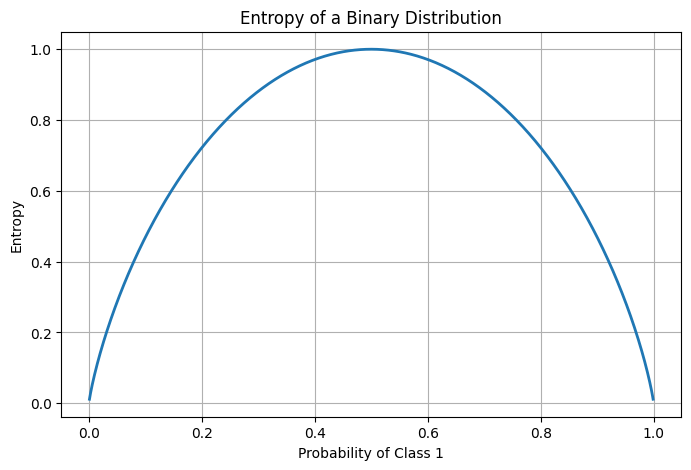

In [4]:
def entropy_from_probability(p):
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return -(p * np.log2(p) + (1 - p) * np.log2(1 - p))


p = np.linspace(0.001, 0.999, 1000)

entropy_values = entropy_from_probability(p)

plt.plot(p, entropy_values, linewidth=2)
plt.xlabel("Probability of Class 1")
plt.ylabel("Entropy")
plt.title("Entropy of a Binary Distribution")
plt.grid(True)
plt.show()

## 2.4 Properties of Entropy

Several important mathematical properties make entropy an effective impurity measure for decision trees.

Recall the binary entropy function:

$$
H(p)
=
-p\log_2(p)
-
(1-p)\log_2(1-p),
$$

where $p$ denotes the probability of one of the classes.

### Minimum Entropy

Entropy is minimized when a node is perfectly pure.

For binary classification,

$$
H(S)=0
$$

when

$$
p=0
\quad \text{or} \quad
p=1.
$$

In these cases, every observation belongs to the same class and there is no uncertainty.

---

### Maximum Entropy

Entropy is maximized when all classes are equally likely.

For binary classification,

$$
H(S)=1
$$

when

$$
p=0.5.
$$

This corresponds to the greatest possible uncertainty because both classes are equally probable.

More generally, for $K$ equally probable classes,

$$
p_i=\frac{1}{K},
\qquad i=1,\ldots,K,
$$

and

$$
H(S)
=
-\sum_{i=1}^{K}
\frac{1}{K}
\log_2\left(\frac{1}{K}\right)
=
\log_2(K).
$$

Thus the maximum entropy increases with the number of classes.

---

### Symmetry

Entropy depends only on the class probabilities, not on class labels.

For binary classification,

$$
H(p)
=
H(1-p).
$$

Therefore,

- A node with 90% positive and 10% negative samples
- A node with 10% positive and 90% negative samples

have exactly the same entropy.

Only the degree of impurity matters.

---

### Concavity

The entropy function is concave and reaches its maximum at a uniform distribution.

For binary classification:

$$
H(p)
=
-p\log_2(p)
-
(1-p)\log_2(1-p).
$$

The curve rises as the class distribution becomes more balanced and falls as the node becomes more pure.

This property is the reason entropy strongly rewards splits that create homogeneous child nodes.

---

### Summary

Entropy satisfies the following desirable properties:

| Property | Result |
|-----------|-----------|
| Non-negative | $H(S)\ge 0$ |
| Pure node | $H(S)=0$ |
| Maximum uncertainty (binary) | $H(S)=1$ |
| Maximum uncertainty ($K$ classes) | $H(S)=\log_2(K)$ |
| Symmetry | $H(p)=H(1-p)$ |
| Depends only on probabilities | Independent of class names |

Entropy provides a rigorous mathematical measure of uncertainty within a node.

The next question is:

> How can we determine whether a candidate split actually reduces uncertainty?

The answer is **Information Gain**, the criterion used by ID3 and many entropy-based decision trees to select the best split.

# 3. Information Gain

Entropy provides a measure of uncertainty within a node.

However, a decision tree does not simply measure entropy—it seeks to **reduce** it.

At every node, the algorithm evaluates candidate splits and asks:

> How much uncertainty is removed after performing this split?

This reduction in uncertainty is known as **Information Gain**.

The best split is the one that produces the largest reduction in entropy.

Consequently, information gain serves as the primary criterion used to select decision tree splits.

## 3.1 Entropy Before and After a Split

Suppose a parent node contains \(N\) observations.

A candidate split divides the node into:

- Left child containing \(N_L\) observations
- Right child containing \(N_R\) observations

where

$$
N = N_L + N_R.
$$

Before splitting, the uncertainty of the node is

$$
H(\text{Parent}).
$$

After splitting, we obtain two child nodes with entropies

$$
H(\text{Left})
$$

and

$$
H(\text{Right}).
$$

Because the child nodes may contain different numbers of observations, their contributions should be weighted according to their sizes.

This leads to the concept of weighted child entropy.

## 3.2 Weighted Child Entropy

The uncertainty after a split is computed as a weighted average of the child node entropies:

$$
H_{\text{children}}
=
\frac{N_L}{N}H(\text{Left})
+
\frac{N_R}{N}H(\text{Right}).
$$

The weighting factors

$$
\frac{N_L}{N}
\quad\text{and}\quad
\frac{N_R}{N}
$$

represent the proportion of observations assigned to each child node.

This weighting is essential.

A small child node should not influence the split quality as strongly as a large child node.

Therefore, the uncertainty after splitting is measured by the expected entropy of the resulting children.

## 3.3 Deriving Information Gain

A useful split should decrease uncertainty.

Therefore we define information gain as

$$
\text{Information Gain}
=
\text{Entropy Before Split}
-
\text{Entropy After Split}.
$$

Substituting the entropy terms gives

$$
IG
=
H(\text{Parent})
-
H_{\text{children}}.
$$

Using the weighted entropy expression,

$$
IG
=
H(\text{Parent})
-
\left(
\frac{N_L}{N}H(\text{Left})
+
\frac{N_R}{N}H(\text{Right})
\right).
$$

Interpretation:

- Large information gain implies a highly informative split.
- Small information gain implies a weak split.
- A perfectly useless split produces

$$
IG = 0.
$$

Decision trees greedily select the split with the largest information gain.

## 3.4 Worked Example

Consider a parent node containing 10 observations:

| Class | Count |
|---------|---------|
| Positive | 5 |
| Negative | 5 |

The parent entropy is

$$
H(\text{Parent})
=
-(0.5\log_2 0.5 + 0.5\log_2 0.5)
=
1.
$$

Now suppose a candidate split produces:

### Left Child

| Class | Count |
|---------|---------|
| Positive | 4 |
| Negative | 1 |

### Right Child

| Class | Count |
|---------|---------|
| Positive | 1 |
| Negative | 4 |

The entropy of each child becomes

$$
H(\text{Left})
=
-(0.8\log_2 0.8 + 0.2\log_2 0.2)
\approx 0.722
$$

and

$$
H(\text{Right})
\approx 0.722.
$$

The weighted child entropy is

$$
H_{\text{children}}
=
\frac{5}{10}(0.722)
+
\frac{5}{10}(0.722)
=
0.722.
$$

Therefore,

$$
IG
=
1 - 0.722
=
0.278.
$$

This split reduces uncertainty and would therefore be considered useful.

In [5]:
def entropy(y):
    """
    Compute entropy of a class label vector.
    """
    _, counts = np.unique(y, return_counts=True)

    probabilities = counts / len(y)

    return -np.sum(probabilities * np.log2(probabilities))

In [6]:
y_pure = np.array([1, 1, 1, 1, 1])

y_balanced = np.array([0, 0, 1, 1])

y_imbalanced = np.array([1, 1, 1, 1, 0])

print(f"Pure entropy: {entropy(y_pure):.3f}")
print(f"Balanced entropy: {entropy(y_balanced):.3f}")
print(f"Imbalanced entropy: {entropy(y_imbalanced):.3f}")

Pure entropy: -0.000
Balanced entropy: 1.000
Imbalanced entropy: 0.722


In [7]:
def information_gain(parent, left_child, right_child):

    n = len(parent)

    n_left = len(left_child)
    n_right = len(right_child)

    parent_entropy = entropy(parent)

    child_entropy = (
        (n_left / n) * entropy(left_child)
        +
        (n_right / n) * entropy(right_child)
    )

    return parent_entropy - child_entropy

In [8]:
parent = np.array([1,1,1,1,1,0,0,0,0,0])

left = np.array([1,1,1,1,0])

right = np.array([1,0,0,0,0])

print(
    f"Information Gain: "
    f"{information_gain(parent,left,right):.3f}"
)

Information Gain: 0.278


## Key Insight

Information gain provides a principled method for evaluating candidate splits.

The decision tree training procedure can therefore be viewed as a sequence of optimization problems:

$$
\text{Choose the split that maximizes}
\quad
IG.
$$

For every feature and every candidate threshold, the algorithm computes the resulting information gain.

The split producing the largest value is selected.

This naturally leads to the next question:

> How does a decision tree efficiently search through thousands of possible splits?

To answer this, we must study the mechanics of split selection.

# 4. Finding the Best Split

We now understand how to evaluate a split using information gain.

The remaining challenge is determining **which split to choose**.

Suppose a feature contains many distinct values:

$$
[12,\;15,\;18,\;22,\;31,\;45].
$$

There are numerous possible thresholds:

$$
x < 13.5
$$

$$
x < 16.5
$$

$$
x < 20
$$

$$
x < 26.5
$$

$$
x < 38
$$

A decision tree systematically evaluates candidate thresholds and selects the one that maximizes information gain.

Thus, split selection can be formulated as

$$
(t^*, j^*)
=
\arg\max_{t,j}
IG(t,j)
$$

where:

- \(j\) denotes a feature
- \(t\) denotes a threshold

The optimal split is the feature-threshold pair that yields the greatest reduction in uncertainty.

## 4.1 Candidate Threshold Generation

For a continuous feature, decision trees do not evaluate every possible real number.

Instead, the feature values are first sorted.

Suppose a feature contains

$$
[2,\;5,\;8,\;12,\;20].
$$

The candidate thresholds are chosen as the midpoints between adjacent values:

$$
\frac{2+5}{2}=3.5
$$

$$
\frac{5+8}{2}=6.5
$$

$$
\frac{8+12}{2}=10
$$

$$
\frac{12+20}{2}=16
$$

Therefore the candidate threshold set becomes

$$
\{3.5,\;6.5,\;10,\;16\}.
$$

This strategy guarantees that every unique partition of the data is considered while avoiding redundant evaluations.

In [9]:
feature_values = np.array([2, 5, 8, 12, 20])

thresholds = (
    feature_values[:-1] +
    feature_values[1:]
) / 2

print("Candidate Thresholds:")
print(thresholds)

Candidate Thresholds:
[ 3.5  6.5 10.  16. ]


## 4.2 Exhaustive Threshold Search

For a single feature, the decision tree performs the following procedure:

1. Generate candidate thresholds.
2. Split the dataset using each threshold.
3. Compute information gain.
4. Store the result.
5. Select the threshold with the largest gain.

Mathematically,

$$
IG(t)
=
H(\text{Parent})
-
H_{\text{children}}(t).
$$

The algorithm evaluates

$$
IG(t_1),
IG(t_2),
\dots,
IG(t_m)
$$

for all candidate thresholds and selects

$$
t^*
=
\arg\max_t IG(t).
$$

This greedy strategy does not guarantee a globally optimal tree.

Instead, it guarantees the locally best split at the current node.

In [10]:
def split_dataset(X_column, y, threshold):

    left_mask = X_column < threshold
    right_mask = ~left_mask

    return (
        y[left_mask],
        y[right_mask]
    )

In [11]:
def find_best_threshold(X_column, y):

    unique_values = np.sort(np.unique(X_column))

    thresholds = (
        unique_values[:-1] +
        unique_values[1:]
    ) / 2

    best_gain = -np.inf
    best_threshold = None

    gains = []

    for threshold in thresholds:

        left_y, right_y = split_dataset(
            X_column,
            y,
            threshold
        )

        gain = information_gain(
            y,
            left_y,
            right_y
        )

        gains.append(gain)

        if gain > best_gain:
            best_gain = gain
            best_threshold = threshold

    return best_threshold, best_gain, thresholds, gains

In [12]:
best_threshold, best_gain, thresholds, gains = (
    find_best_threshold(X[:, 0], y)
)

print(f"Best Threshold: {best_threshold:.3f}")
print(f"Best Information Gain: {best_gain:.3f}")

Best Threshold: -0.000
Best Information Gain: 0.406


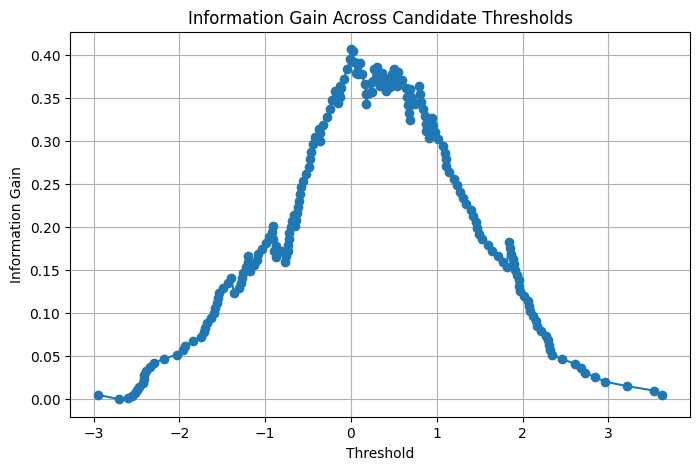

In [13]:
plt.plot(thresholds, gains, marker="o")

plt.xlabel("Threshold")
plt.ylabel("Information Gain")
plt.title("Information Gain Across Candidate Thresholds")

plt.grid(True)
plt.show()

## 4.3 Selecting the Best Feature

Real datasets typically contain multiple features.

Suppose

$$
X
=
[x_1,x_2,\dots,x_d].
$$

The decision tree must determine:

1. Which feature should be split?
2. Which threshold should be used?

The complete optimization problem becomes

$$
(j^*, t^*)
=
\arg\max_{j,t}
IG(j,t).
$$

The algorithm evaluates:

- Every feature
- Every candidate threshold within that feature

and chooses the combination that produces the largest information gain.

This process is repeated recursively at every node until a stopping criterion is reached.

## Computational Considerations

Although conceptually simple, split selection can become computationally expensive.

For:

- \(n\) samples
- \(d\) features

a decision tree may evaluate thousands of candidate splits during training.

This computational burden motivates many later developments in tree-based learning:

- Random Forests reduce variance through averaging.
- Gradient Boosting improves predictive performance through sequential learning.
- XGBoost introduces sophisticated optimization techniques for efficient split selection.

Before exploring ensembles, we must first understand how repeated split selection produces an entire decision tree.

# 5. Building Decision Trees Recursively

A decision tree is constructed by repeatedly applying the split-selection procedure introduced in the previous section.

At each node:

1. Compute the best feature and threshold.
2. Split the data.
3. Create two child nodes.
4. Repeat the process for each child.

This recursive procedure continues until a stopping criterion is satisfied.

Conceptually, the algorithm can be written as:

```text
BuildTree(Data)

    Find Best Split

    If stopping criterion met:
        Create Leaf Node

    Else:
        Split Data
        Build Left Subtree
        Build Right Subtree
```

Because each node applies the same procedure to a smaller subset of the data, decision trees are naturally recursive structures.

## 5.1 Stopping Criteria

If splitting continues indefinitely, the tree may eventually memorize the training data.

To prevent uncontrolled growth, tree construction terminates when one or more stopping criteria are met.

Common stopping conditions include:

### Pure Node

All samples belong to the same class.

$$
H(S)=0.
$$

No further uncertainty remains.

---

### Maximum Depth

The tree reaches a predefined depth:

$$
\text{Depth} \ge d_{\max}.
$$

This limits model complexity.

---

### Minimum Samples per Split

Splitting is not performed when the node contains too few observations.

$$
N < N_{\min}.
$$

This prevents unstable decisions based on very small sample sizes.

---

The choice of stopping criteria directly influences the bias-variance tradeoff of the resulting model.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=RANDOM_STATE
)

tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

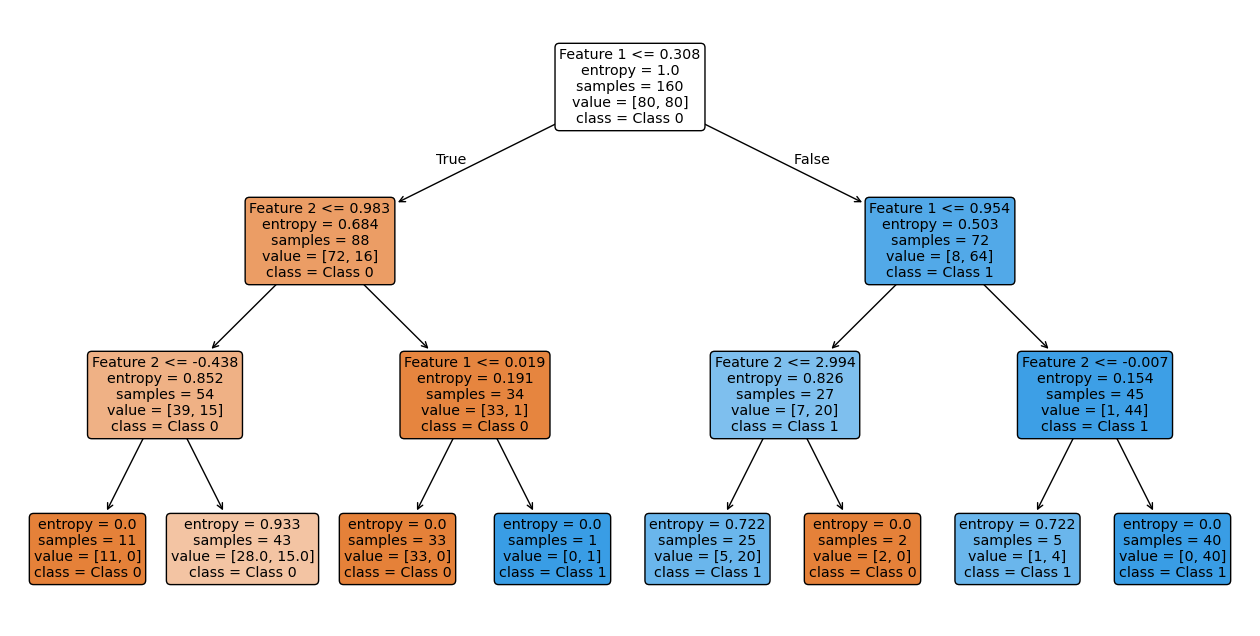

In [15]:
plt.figure(figsize=(16, 8))

plot_tree(
    tree,
    filled=True,
    rounded=True,
    feature_names=["Feature 1", "Feature 2"],
    class_names=["Class 0", "Class 1"]
)

plt.show()

## Interpreting the Tree

Each internal node contains a decision rule of the form

$$
x_j < t.
$$

The tree recursively partitions the feature space into smaller and more homogeneous regions.

Several quantities displayed in the visualization are particularly important:

### Entropy

Measures node impurity.

$$
H(S)
=
-\sum_i p_i \log_2(p_i).
$$

Lower entropy indicates greater purity.

---

### Samples

The number of training observations reaching the node.

---

### Value

The class distribution within the node.

For example,

$$
[30,\;10]
$$

indicates 30 observations from one class and 10 from the other.

---

### Predicted Class

The majority class within the node.

Leaf nodes produce the final prediction returned by the model.

In [16]:
train_accuracy = tree.score(X_train, y_train)
test_accuracy = tree.score(X_test, y_test)

print(f"Training Accuracy: {train_accuracy:.3f}")
print(f"Testing Accuracy:  {test_accuracy:.3f}")

Training Accuracy: 0.869
Testing Accuracy:  0.850


## Key Insight

A decision tree can be viewed as a sequence of locally optimal decisions.

At each node, the algorithm chooses the split that maximizes information gain:

$$
(j^*,t^*)
=
\arg\max_{j,t}
IG(j,t).
$$

By recursively applying this rule, the algorithm constructs a hierarchical representation of the data.

However, this greedy strategy introduces an important challenge.

Because each split is optimized independently, deep trees can become extremely sensitive to noise and may memorize the training set.

This phenomenon is known as **overfitting** and represents one of the primary limitations of individual decision trees.

In the next section, we will investigate how tree depth affects model complexity and generalization performance.

# 6. Overfitting and Generalization

Decision trees are highly flexible models.

As tree depth increases, the model gains the ability to create increasingly complex decision boundaries.

While this often improves training performance, it can also lead to memorization of noise rather than learning genuine patterns.

This phenomenon is known as **overfitting**.

The tradeoff can be understood through the concepts of bias and variance:

### High Bias

The model is too simple to capture underlying patterns.

Typical symptom:

- Poor training performance
- Poor testing performance

---

### High Variance

The model is overly sensitive to the training data.

Typical symptom:

- Excellent training performance
- Poor testing performance

---

As depth increases, decision trees generally move from high bias toward high variance.

The goal is to identify a level of complexity that generalizes well to unseen data.

In [17]:
depths = range(1, 16)

train_scores = []
test_scores = []

for depth in depths:

    model = DecisionTreeClassifier(
        criterion="entropy",
        max_depth=depth,
        random_state=RANDOM_STATE
    )

    model.fit(X_train, y_train)

    train_scores.append(
        model.score(X_train, y_train)
    )

    test_scores.append(
        model.score(X_test, y_test)
    )

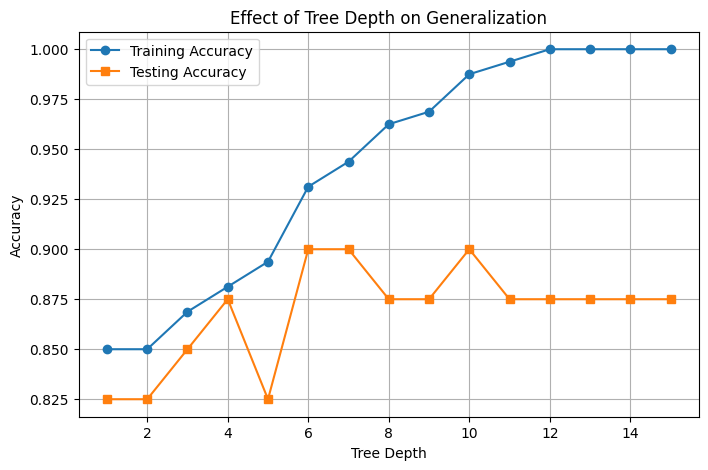

In [18]:
plt.plot(depths, train_scores, marker="o", label="Training Accuracy")
plt.plot(depths, test_scores, marker="s", label="Testing Accuracy")

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Effect of Tree Depth on Generalization")

plt.legend()
plt.grid(True)

plt.show()

## From Trees to Ensembles

The previous experiment highlights a fundamental weakness of decision trees.

Small changes in the training data can produce dramatically different tree structures.

Consequently, individual trees often exhibit high variance.

Rather than relying on a single tree, we can combine multiple trees to obtain a more stable and powerful predictor.

This idea forms the foundation of **ensemble learning**.

An ensemble combines predictions from multiple models:

$$
\hat{f}_{ensemble}(x)
=
\frac{1}{M}
\sum_{m=1}^{M}
\hat{f}_m(x).
$$

Although individual models may be imperfect, their collective prediction is often substantially more accurate.

The two most influential ensemble approaches are:

1. **Bagging (Bootstrap Aggregation)**
2. **Boosting**

These approaches lead directly to Random Forests and Gradient Boosting.

# 7. Random Forests: Reducing Variance Through Bagging

Random Forests address the instability of individual trees by combining many independently trained decision trees.

Each tree is trained on a different bootstrap sample of the training data.

A bootstrap sample is generated by sampling with replacement.

An observation may therefore:

- Appear multiple times
- Not appear at all

For a dataset containing \(n\) observations,

the probability that a particular observation is not selected in one draw is

$$
1-\frac{1}{n}.
$$

After \(n\) draws,

$$
\left(1-\frac{1}{n}\right)^n.
$$

Taking the limit,

$$
\lim_{n\to\infty}
\left(1-\frac{1}{n}\right)^n
=
e^{-1}
\approx 0.368.
$$

Thus approximately 36.8% of observations are excluded from a bootstrap sample.

These observations are known as **Out-of-Bag (OOB)** samples and can be used for validation.

In addition to bootstrap sampling, Random Forests randomly select subsets of features during split selection.

This decorrelates individual trees and further reduces variance.

In [19]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)

tree_acc = tree.score(X_test, y_test)
rf_acc = rf.score(X_test, y_test)

print(f"Decision Tree Accuracy : {tree_acc:.3f}")
print(f"Random Forest Accuracy : {rf_acc:.3f}")

Decision Tree Accuracy : 0.850
Random Forest Accuracy : 0.900


# 8. Gradient Boosting: Reducing Bias Through Sequential Learning

Bagging improves performance by averaging independent models.

Boosting takes a fundamentally different approach.

Instead of training trees independently, boosting trains trees sequentially.

Each new tree focuses on correcting the mistakes made by previous trees.

Suppose the current model prediction is

$$
\hat{y}.
$$

The residual error is

$$
r = y - \hat{y}.
$$

Rather than fitting the target directly, the next tree is trained to predict these residuals.

The updated model becomes

$$
F_m(x)
=
F_{m-1}(x)
+
\eta h_m(x),
$$

where

- \(F_{m-1}\) is the current model
- \(h_m\) is the newly trained tree
- \(\eta\) is the learning rate

This process resembles gradient descent performed in function space and forms the basis of Gradient Boosting Machines (GBMs).

# 9. XGBoost: Regularized Gradient Boosting

While Gradient Boosting is highly effective, it suffers from several practical limitations:

- Computational cost
- Overfitting
- Scalability challenges

XGBoost addresses these limitations through regularization, second-order optimization, efficient split search, and parallel computation.

The objective function optimized by XGBoost is

$$
\text{Obj}
=
L
+
\Omega(f),
$$

where

$$
L
$$

represents the training loss and

$$
\Omega(f)
$$

penalizes model complexity.

A common regularization term is

$$
\Omega(f)
=
\gamma T
+
\frac{\lambda}{2}
\sum_{j=1}^{T}
w_j^2,
$$

where

- \(T\) is the number of leaves
- \(w_j\) is the score assigned to leaf \(j\)
- \(\gamma\) penalizes excessive splitting
- \(\lambda\) controls leaf weight magnitudes

Unlike classical Gradient Boosting, XGBoost uses both first- and second-order derivatives to guide optimization, leading to more accurate split evaluation and faster convergence.

## XGBoost Split Gain

One of the most important innovations in XGBoost is its split evaluation criterion.

For a candidate split, the gain is computed as

$$
\text{Gain}
=
\frac{1}{2}
\left(
\frac{G_L^2}{H_L+\lambda}
+
\frac{G_R^2}{H_R+\lambda}
-
\frac{G^2}{H+\lambda}
\right)
-\gamma,
$$

where

$$
G=\sum g_i
$$

is the sum of gradients and

$$
H=\sum h_i
$$

is the sum of Hessians.

Interpretation:

- Larger gain indicates a better split.
- Larger \(\gamma\) discourages unnecessary splits.
- Larger \(\lambda\) increases regularization.
- The Hessian term provides curvature information that improves optimization.

This criterion allows XGBoost to evaluate splits more effectively than traditional decision tree algorithms.

# 10. Conclusion

The evolution of tree-based learning can be viewed as a sequence of increasingly sophisticated solutions to the limitations of earlier methods.

$$
\text{Entropy}
\rightarrow
\text{Information Gain}
\rightarrow
\text{Decision Trees}
\rightarrow
\text{Random Forests}
\rightarrow
\text{Gradient Boosting}
\rightarrow
\text{XGBoost}
$$

Key takeaways:

- Entropy measures uncertainty within a node.
- Information Gain identifies informative splits.
- Decision Trees recursively partition feature space.
- Random Forests reduce variance through bagging.
- Gradient Boosting reduces bias through sequential learning.
- XGBoost enhances Gradient Boosting through regularization and second-order optimization.

Together, these algorithms form one of the most important families of models in modern machine learning and remain highly competitive across a wide range of real-world prediction tasks.